DAY4

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
data = pd.read_csv("../data/flood_cleaned.csv")

X = data.drop("FloodRisk", axis=1)
y = data["FloodRisk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Random Forest Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      4821
           1       0.92      0.91      0.92      5179

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

ROC AUC: 0.9766670355394288


In [4]:
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Report:")
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

a:\AI-Disaster-Prediction-System\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:04:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      4821
           1       0.95      0.94      0.94      5179

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000

ROC AUC: 0.9880934400765398


In [7]:
import joblib

# Save model
joblib.dump(xgb, "../model/flood_xgb_model.pkl")

# # Save scaler (important)
# joblib.dump(scaler, "../model/scaler.pkl")

print("Model saved successfully")

Model saved successfully


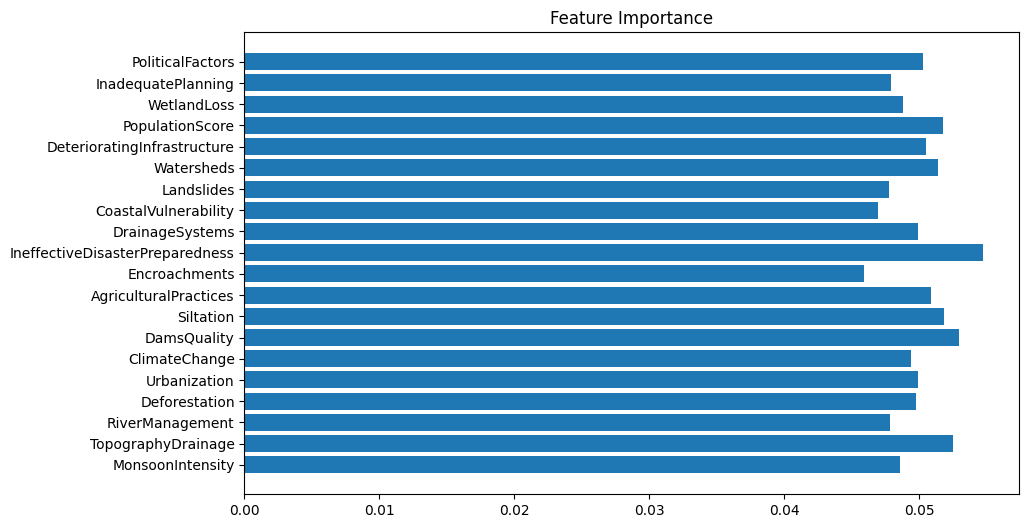

In [8]:
import matplotlib.pyplot as plt

importance = xgb.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()